# Analisi Dataset: ISTANBUL STOCK EXCHANGE

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('data_akbilgic.xlsx', header=1)
df.head()

/Users/sassa04/Matematica per l'IA/MIAenv/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,date,ISE,ISE.1,SP,DAX,FTSE,NIKKEI,BOVESPA,EU,EM
0,2009-01-05,0.035754,0.038376,-0.004679,0.002193,0.003894,0.000000,0.031190,0.012698,0.028524
1,2009-01-06,0.025426,0.031813,0.007787,0.008455,0.012866,0.004162,0.018920,0.011341,0.008773
2,2009-01-07,-0.028862,-0.026353,-0.030469,-0.017833,-0.028735,0.017293,-0.035899,-0.017073,-0.020015
3,2009-01-08,-0.062208,-0.084716,0.003391,-0.011726,-0.000466,-0.040061,0.028283,-0.005561,-0.019424
4,2009-01-09,0.009860,0.009658,-0.021533,-0.019873,-0.012710,-0.004474,-0.009764,-0.010989,-0.007802


In [2]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     536 non-null    datetime64[ns]
 1   ISE      536 non-null    float64       
 2   ISE.1    536 non-null    float64       
 3   SP       536 non-null    float64       
 4   DAX      536 non-null    float64       
 5   FTSE     536 non-null    float64       
 6   NIKKEI   536 non-null    float64       
 7   BOVESPA  536 non-null    float64       
 8   EU       536 non-null    float64       
 9   EM       536 non-null    float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 42.0 KB
None
                                date         ISE       ISE.1          SP  \
count                            536  536.000000  536.000000  536.000000   
mean   2010-01-26 03:37:36.716418048    0.001629    0.001552    0.000643   
min              2009-01-05 00:00:00   -0.062208   -0.084716  

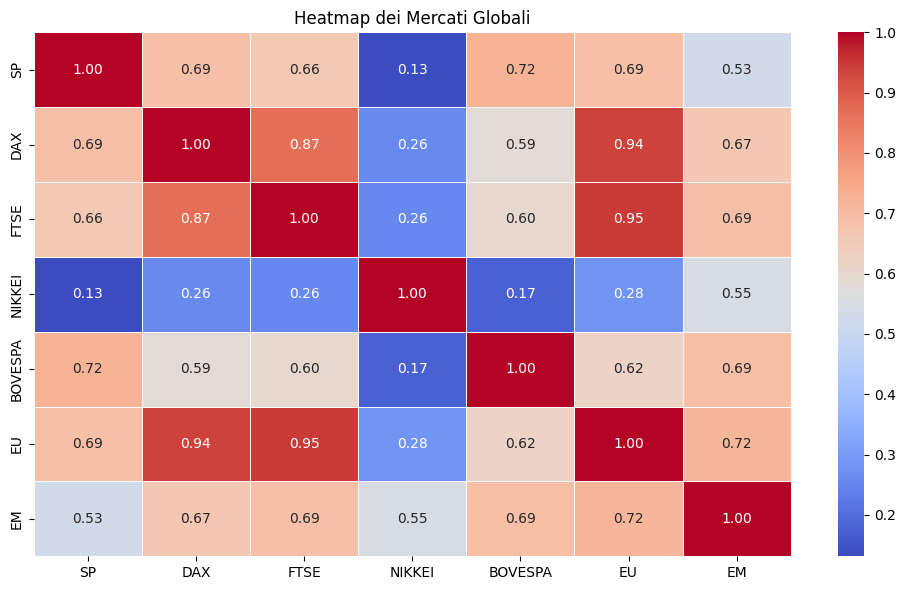

In [3]:
# Si imposta la data come indice
if 'date' in df.columns:
    df.set_index('date', inplace=True)
    
# Si eliminano gli ISE che rappresentano il target (ISE.1 in USD)
X_raw = df.drop(columns=['ISE', 'ISE.1'])
# X_raw.head()

import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(X_raw.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap dei Mercati Globali")
plt.tight_layout()
plt.show()

## 1. Pre-processing e target

Dimensione del training set: (375, 7)
Dimensione del test set: (161, 7)


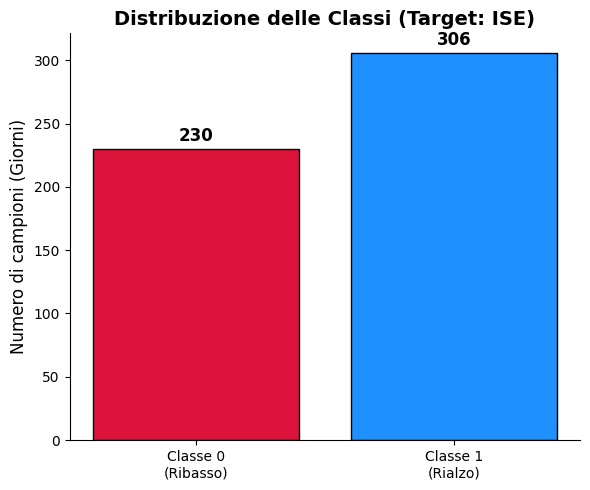

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Preparo le features e il target
X_raw = df.drop(columns=['ISE', 'ISE.1'])
y = (df['ISE'] > 0).astype(int)  # Classificazione binaria (1 se ISE > 0, altrimenti 0)

# 2. Split dei dati (70% training, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, random_state=42)

# 3. Standardizzazione dei dati
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print(f"Dimensione del training set: {X_train_scaled.shape}")
print(f"Dimensione del test set: {X_test_scaled.shape}")

# Calcoliamo quanti giorni ci sono per la classe 0 e per la classe 1
conteggi = y.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 5))

# Creiamo il grafico a barre
barre = ax.bar(['Classe 0\n(Ribasso)', 'Classe 1\n(Rialzo)'], conteggi.values, color=['crimson', 'dodgerblue'], edgecolor='black')

ax.set_title('Distribuzione delle Classi (Target: ISE)', fontsize=14, fontweight='bold')
ax.set_ylabel('Numero di campioni (Giorni)', fontsize=12)

# Aggiungiamo il numero esatto sopra ogni barra per massima chiarezza
for barra in barre:
    altezza = barra.get_height()
    ax.annotate(f'{altezza}',
                xy=(barra.get_x() + barra.get_width() / 2, altezza),
                xytext=(0, 3),  # 3 punti di offset verticale
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Rimuoviamo i bordi in alto e a destra per un look più "pulito" e accademico
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 2. PCA (Principal Component Analysis)

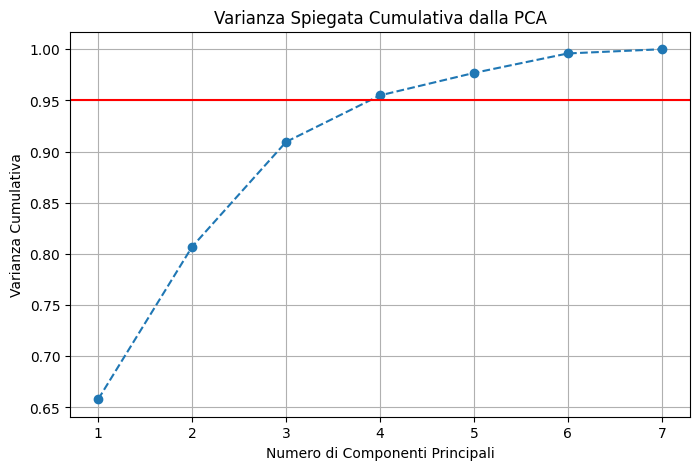

Numero di Componenti Principali: 4


In [5]:
from sklearn.decomposition import PCA

# 1. Inizializzazione della PCA
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Plot Dela varianza spiegata cumulativa
varianza_spiegata = pca_full.explained_variance_ratio_
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_spiegata) + 1), np.cumsum(varianza_spiegata), marker='o', linestyle='--')
plt.title('Varianza Spiegata Cumulativa dalla PCA')
plt.xlabel('Numero di Componenti Principali')
plt.ylabel('Varianza Cumulativa')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-')
plt.show()

# Applicazione PCA
pca = PCA(n_components=0.95) # Mantengo il 95% della varianza
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Numero di Componenti Principali: {pca.n_components_}")

### 2.1 PCA 3D Scatter Plot

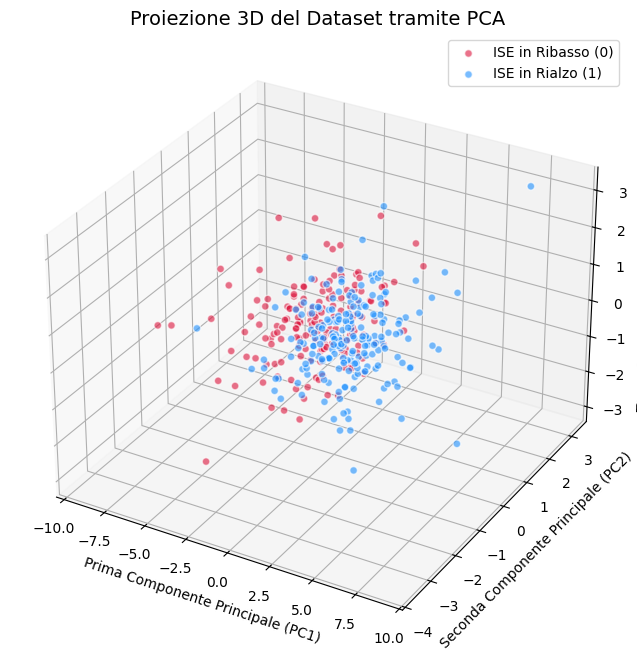

In [6]:
from mpl_toolkits.mplot3d import Axes3D

# Applichiamo la PCA estraendo esattamente 3 componenti per la visualizzazione
pca_3d = PCA(n_components=3)
X_train_pca3d = pca_3d.fit_transform(X_train_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Separizziamo i punti in base al target (0 o 1) per colorarli diversamente
idx_ribasso = (y_train == 0)
idx_rialzo = (y_train == 1)

ax.scatter(X_train_pca3d[idx_ribasso, 0], X_train_pca3d[idx_ribasso, 1], X_train_pca3d[idx_ribasso, 2], 
           c='crimson', label='ISE in Ribasso (0)', alpha=0.6, edgecolors='w', s=30)
ax.scatter(X_train_pca3d[idx_rialzo, 0], X_train_pca3d[idx_rialzo, 1], X_train_pca3d[idx_rialzo, 2], 
           c='dodgerblue', label='ISE in Rialzo (1)', alpha=0.6, edgecolors='w', s=30)

ax.set_title('Proiezione 3D del Dataset tramite PCA', fontsize=14)
ax.set_xlabel('Prima Componente Principale (PC1)')
ax.set_ylabel('Seconda Componente Principale (PC2)')
ax.set_zlabel('Terza Componente Principale (PC3)')
ax.legend()
plt.show()

## 3. Supervised Learning

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

models = {
    'LDA' : LinearDiscriminantAnalysis(),
    'KNN' : KNeighborsClassifier(n_neighbors=5),
    'SVM' : SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'MLP' : MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
}


acc_train_list = []
acc_test_list = []
acc_labels = list(models.keys())

print(f"MODELLI con PCA")
for name, model in models.items():
    # Addestramento del modello
    model.fit(X_train_pca, y_train)

    # Predizione sui dati di training e test
    y_train_pred = model.predict(X_train_pca)
    y_test_pred = model.predict(X_test_pca)
    
    # Calcolo dell'accuratezza
    acc_train = accuracy_score(y_train, y_train_pred) *100
    acc_test = accuracy_score(y_test, y_test_pred) *100
    
    acc_train_list.append(acc_train)
    acc_test_list.append(acc_test)
    
    print(f"{name} - Accuratezza Training: {acc_train:.4f}%, Accuratezza Test: {acc_test:.4f}%")

MODELLI con PCA
LDA - Accuratezza Training: 72.0000%, Accuratezza Test: 75.1553%
KNN - Accuratezza Training: 75.2000%, Accuratezza Test: 72.6708%
SVM - Accuratezza Training: 74.6667%, Accuratezza Test: 77.0186%
MLP - Accuratezza Training: 74.1333%, Accuratezza Test: 77.6398%


### 3.1. Matrice di confusione a confronto

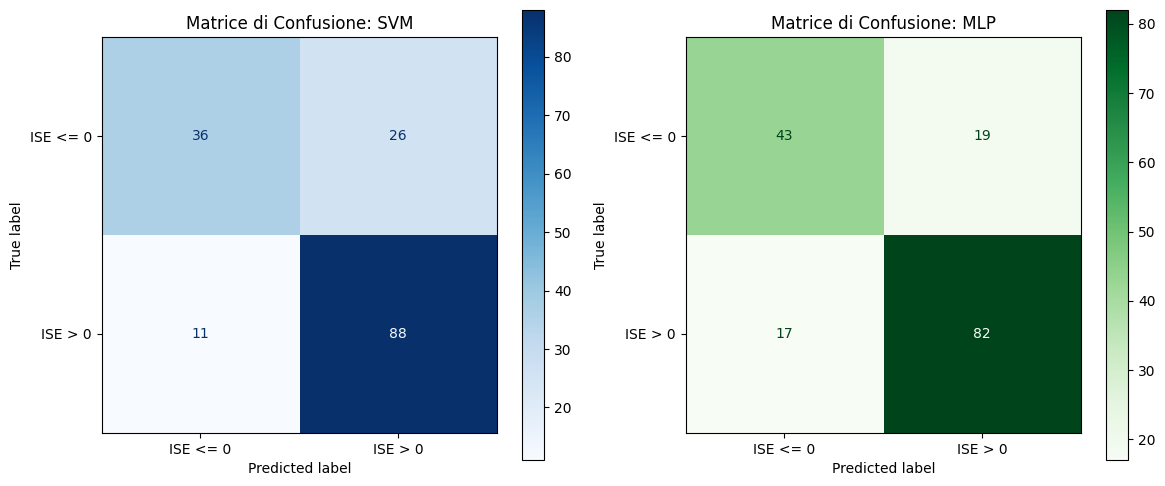

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice per SVM
y_pred_svm = models['SVM'].predict(X_test_pca)
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['ISE <= 0', 'ISE > 0'])
disp_svm.plot(ax=axs[0], cmap='Blues', values_format='d')
axs[0].set_title('Matrice di Confusione: SVM')

# 2. Matrice per MLP
y_pred_mlp = models['MLP'].predict(X_test_pca)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=['ISE <= 0', 'ISE > 0'])
disp_mlp.plot(ax=axs[1], cmap='Greens', values_format='d')
axs[1].set_title('Matrice di Confusione: MLP')

plt.tight_layout()
plt.show()



# 4. Plot finali

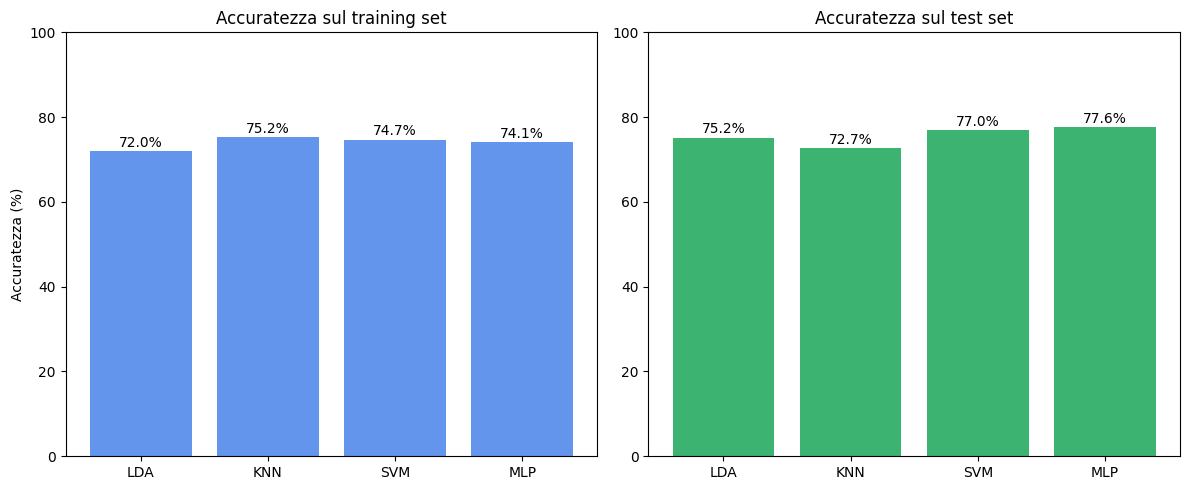

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].bar(acc_labels, acc_train_list, color='cornflowerblue')
axs[0].set_title('Accuratezza sul training set')
axs[0].set_ylabel('Accuratezza (%)')
axs[0].set_ylim(0, 100)
for i, v in enumerate(acc_train_list):
    axs[0].text(i, v + 1, f"{v:.1f}%", ha='center')

axs[1].bar(acc_labels, acc_test_list, color='mediumseagreen')
axs[1].set_title('Accuratezza sul test set')
axs[1].set_ylim(0, 100)
for i, v in enumerate(acc_test_list):
    axs[1].text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

/Users/sassa04/Matematica per l'IA/MIAenv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Acc. No PCA (%),Acc. Con PCA (%),Acc. Con FDA (%)
Modello,,,
LDA,72.05,75.16,72.05
KNN (k=5),73.91,72.67,69.57
Kernel SVM,75.16,77.02,74.53
MLP Network,67.70,77.64,72.67


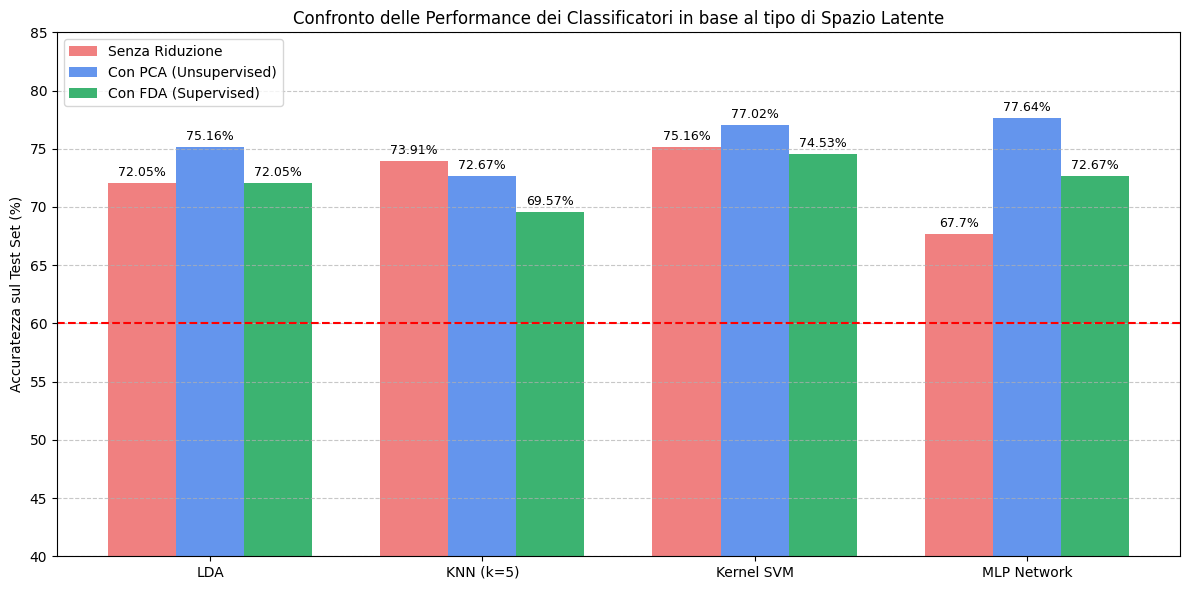

In [10]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

fda = LinearDiscriminantAnalysis(n_components=1)

# IMPORTANTE: Essendo un metodo supervisionato, richiede anche 'y_train' per calcolare la proiezione
X_train_fda = fda.fit_transform(X_train_scaled, y_train)
X_test_fda = fda.transform(X_test_scaled)

# Definiamo i classificatori da testare
classificatori = {
    'LDA': LinearDiscriminantAnalysis(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Kernel SVM': SVC(kernel='rbf', C=1.0, random_state=42),
    'MLP Network': MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
}

# Dizionario per raccogliere i punteggi sul Test Set
risultati = {
    'Modello': [],
    'Acc. No PCA (%)': [],
    'Acc. Con PCA (%)': [],
    'Acc. Con FDA (%)': []
}

for name, clf in classificatori.items():
    risultati['Modello'].append(name)
    
    # 1. Test senza riduzione (Dati solo scalati)
    clf.fit(X_train_scaled, y_train)
    acc_no_pca = accuracy_score(y_test, clf.predict(X_test_scaled)) * 100
    risultati['Acc. No PCA (%)'].append(round(acc_no_pca, 2))
    
    # 2. Test con riduzione PCA
    clf.fit(X_train_pca, y_train)
    acc_pca = accuracy_score(y_test, clf.predict(X_test_pca)) * 100
    risultati['Acc. Con PCA (%)'].append(round(acc_pca, 2))
    
    # 3. Test con riduzione FDA
    clf.fit(X_train_fda, y_train)
    acc_fda = accuracy_score(y_test, clf.predict(X_test_fda)) * 100
    risultati['Acc. Con FDA (%)'].append(round(acc_fda, 2))

# Convertiamo in un DataFrame Pandas per una visualizzazione pulita in stile Tabella
df_risultati = pd.DataFrame(risultati)
df_risultati.set_index('Modello', inplace=True)
display(df_risultati)

# Configurazione posizioni barre
labels = df_risultati.index
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width, df_risultati['Acc. No PCA (%)'], width, label='Senza Riduzione', color='lightcoral')
rects2 = ax.bar(x, df_risultati['Acc. Con PCA (%)'], width, label='Con PCA (Unsupervised)', color='cornflowerblue')
rects3 = ax.bar(x + width, df_risultati['Acc. Con FDA (%)'], width, label='Con FDA (Supervised)', color='mediumseagreen')

ax.set_ylabel('Accuratezza sul Test Set (%)')
ax.set_title('Confronto delle Performance dei Classificatori in base al tipo di Spazio Latente')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(40, 85) # zoom visivo per evidenziare le differenze tra i modelli
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.axhline(y=60, color='r', linestyle='--', label = 'Baseline (Maggioranza)')  # Linea di riferimento al 50%

# Funzione per aggiungere le etichette numeriche sopra le barre
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

## 5. Ottimizzazione e Valutazione finale

Avvio Grid Search per SVM...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

--- RISULTATI GRID SEARCH ---
Migliori iperparametri trovati: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuratezza in Cross-Validation: 71.47%

--- REPORT DI CLASSIFICAZIONE SUL TEST SET ---
              precision    recall  f1-score   support

 Ribasso (0)       0.70      0.65      0.67        62
  Rialzo (1)       0.79      0.83      0.81        99

    accuracy                           0.76       161
   macro avg       0.75      0.74      0.74       161
weighted avg       0.76      0.76      0.76       161



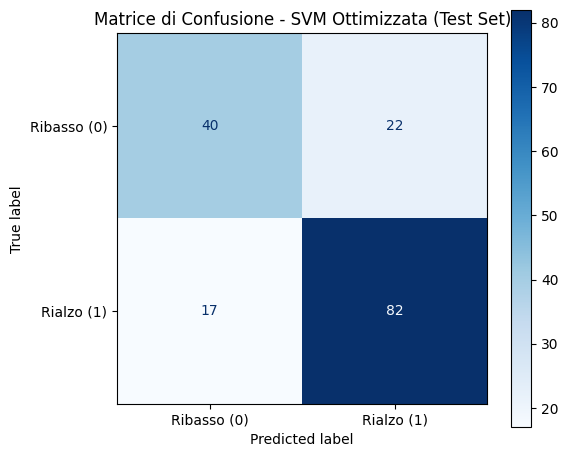

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# ==========================================
# 1. GRID SEARCH (Ottimizzazione SVM)
# ==========================================
print("Avvio Grid Search per SVM...")

# Definiamo la griglia degli iperparametri da esplorare
param_grid = {
    'C': [0.1, 1, 10, 50, 100],          # Costante di regolarizzazione (Soft vs Hard margin)
    'gamma': ['scale', 'auto', 0.01, 0.1], # Coefficiente del kernel
    'kernel': ['rbf', 'linear', 'poly']    # Tipo di trasformazione non lineare
}

# Inizializziamo la Grid Search con 5-fold Cross Validation
grid_search = GridSearchCV(
    estimator=SVC(random_state=42), 
    param_grid=param_grid, 
    cv=5,                 # Divide il training set in 5 parti per validare internamente
    scoring='accuracy',   # Metrica da massimizzare
    n_jobs=-1,            # Usa tutti i core del processore per velocizzare
    verbose=1             # Stampa a video l'avanzamento
)

# Addestriamo la Grid Search (usiamo i dati PCA come esempio)
grid_search.fit(X_train_pca, y_train)

# Estraiamo il modello vincitore
best_svm = grid_search.best_estimator_

print("\n--- RISULTATI GRID SEARCH ---")
print(f"Migliori iperparametri trovati: {grid_search.best_params_}")
print(f"Accuratezza in Cross-Validation: {grid_search.best_score_ * 100:.2f}%")

# ==========================================
# 2. METRICHE DI VALUTAZIONE AGGIUNTIVE
# ==========================================
# Facciamo le previsioni sul Test Set MAI visto prima usando il modello ottimizzato
y_pred_best = best_svm.predict(X_test_pca)

print("\n--- REPORT DI CLASSIFICAZIONE SUL TEST SET ---")
# Il classification_report calcola automaticamente Precision, Recall e F1-Score
print(classification_report(y_test, y_pred_best, target_names=['Ribasso (0)', 'Rialzo (1)']))

# ==========================================
# 3. MATRICE DI CONFUSIONE
# ==========================================
# Calcoliamo la matrice
cm = confusion_matrix(y_test, y_pred_best)

# Disegniamo la matrice
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ribasso (0)', 'Rialzo (1)'])
disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title('Matrice di Confusione - SVM Ottimizzata (Test Set)', fontsize=12)
plt.tight_layout()
plt.show()

### 5.1 Grafico 3D di SVM col grid search

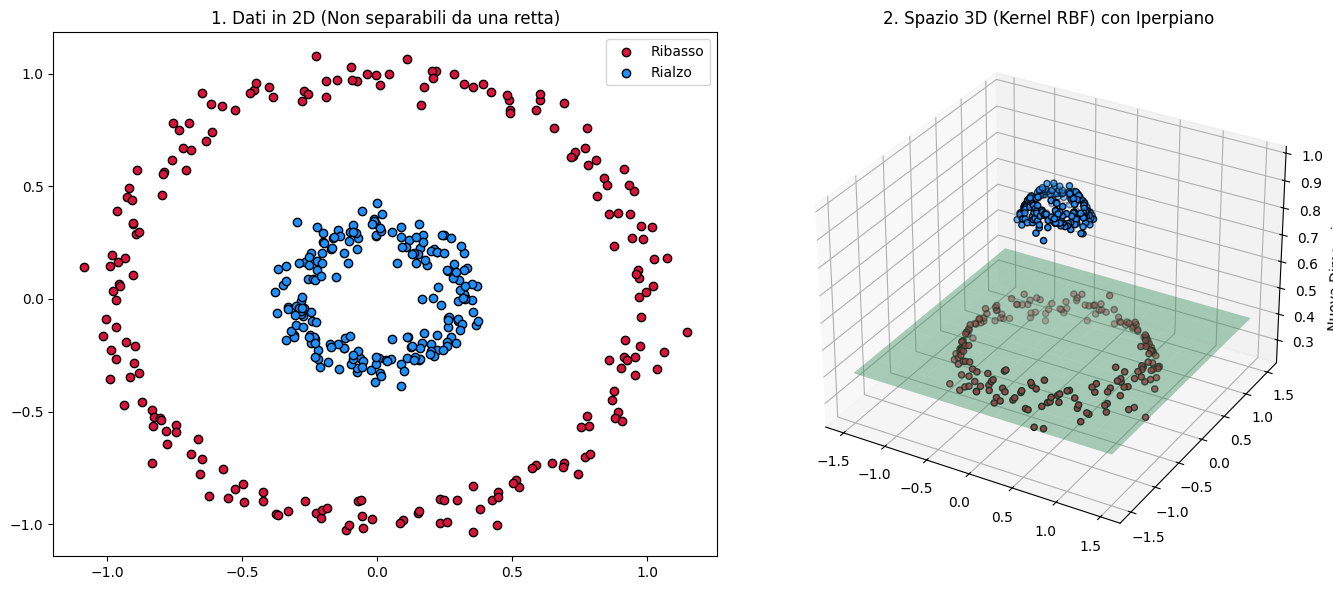

In [12]:
from sklearn.datasets import make_circles

X_syn, y_syn = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=42)

# Applichiamo la trasformazione RBF (solleviamo i punti al centro)
Z = np.exp(-(X_syn[:, 0]**2 + X_syn[:, 1]**2))

fig = plt.figure(figsize=(14, 6))

# Plot 2D (Originale)
ax1 = fig.add_subplot(121)
ax1.scatter(X_syn[y_syn==0, 0], X_syn[y_syn==0, 1], c='crimson', label='Ribasso', edgecolors='k')
ax1.scatter(X_syn[y_syn==1, 0], X_syn[y_syn==1, 1], c='dodgerblue', label='Rialzo', edgecolors='k')
ax1.set_title('1. Dati in 2D (Non separabili da una retta)', fontsize=12)
ax1.legend()

# Plot 3D (Dopo il Kernel RBF)
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_syn[y_syn==0, 0], X_syn[y_syn==0, 1], Z[y_syn==0], c='crimson', edgecolors='k')
ax2.scatter(X_syn[y_syn==1, 0], X_syn[y_syn==1, 1], Z[y_syn==1], c='dodgerblue', edgecolors='k')

# Disegniamo l'iperpiano separatore (il piano piatto che taglia i dati)
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 10), np.linspace(-1.5, 1.5, 10))
zz = np.full(xx.shape, 0.4) # Altezza del piano di taglio
ax2.plot_surface(xx, yy, zz, alpha=0.4, color='mediumseagreen')
ax2.set_title('2. Spazio 3D (Kernel RBF) con Iperpiano', fontsize=12)
ax2.set_zlabel('Nuova Dimensione RBF')

plt.tight_layout()
plt.show()


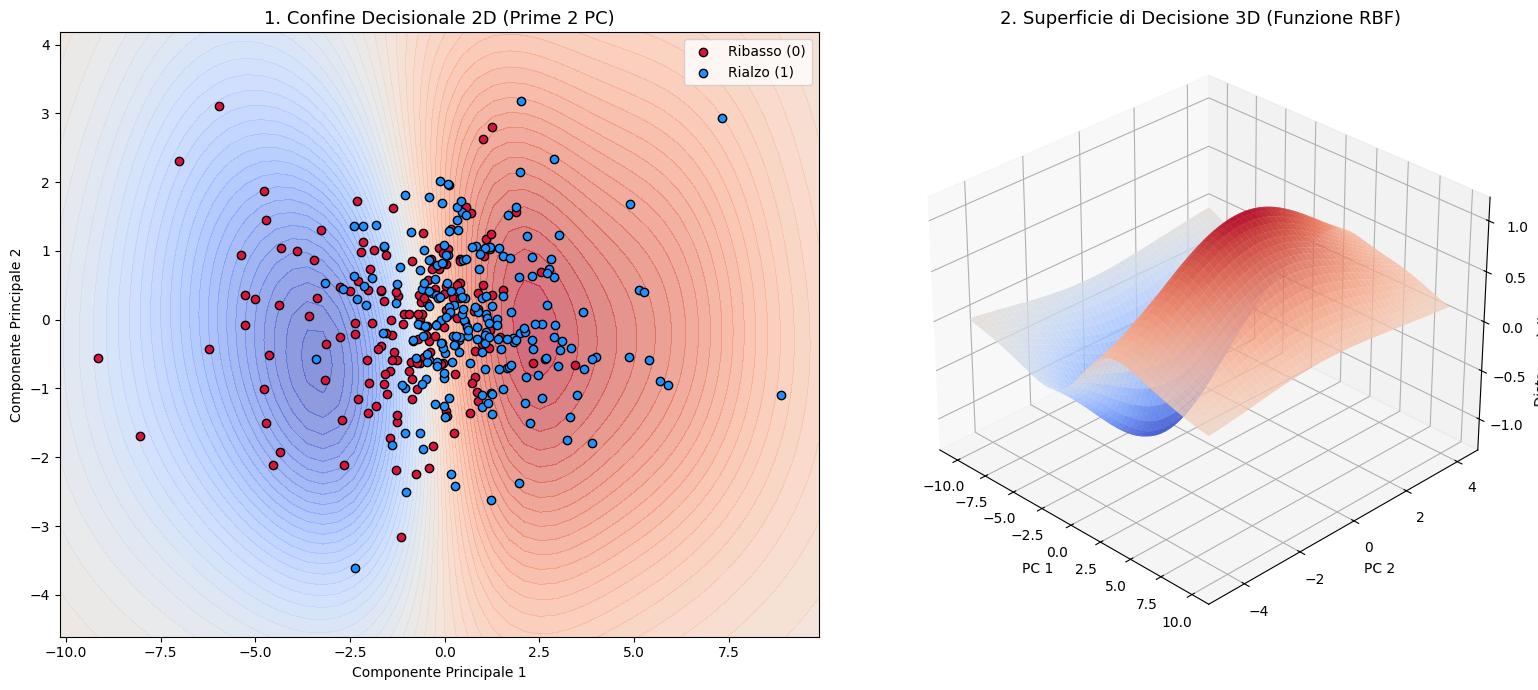

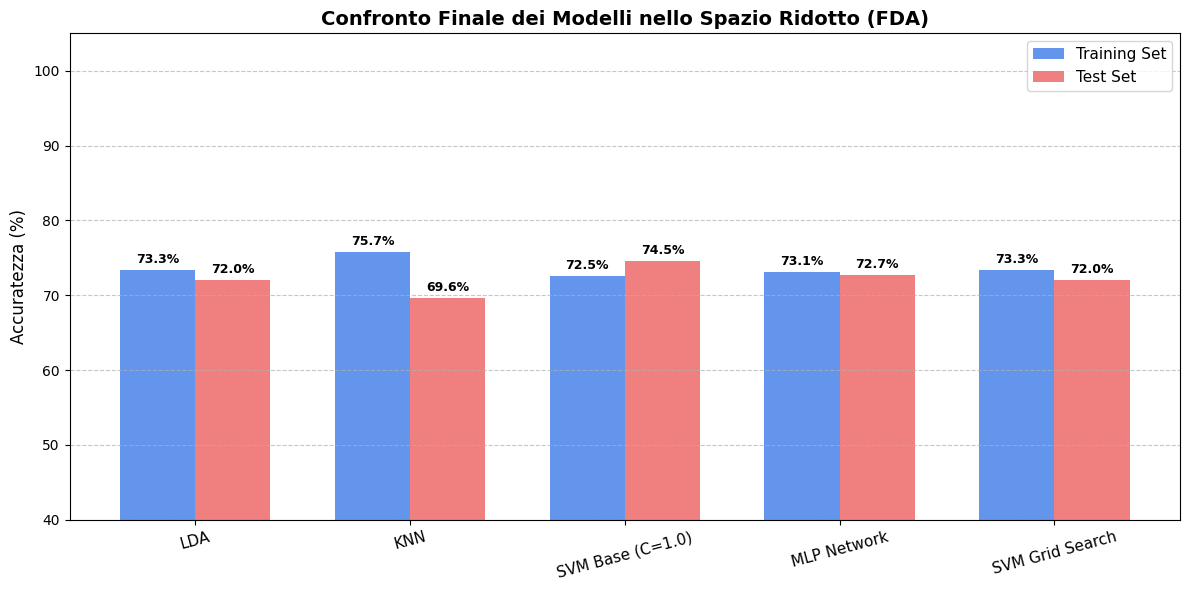

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier


# 1. Prepariamo i dati visivi (prime due componenti PCA)
X_vis_train = X_train_pca[:, :2]

# 2. Creiamo una copia del modello vincitore della Grid Search
# (Sostituisci i valori con i tuoi best_params_ se differiscono)
svm_vis = SVC(kernel='rbf', C=0.1, gamma=0.1)
svm_vis.fit(X_vis_train, y_train)

# 3. Creiamo una griglia di punti per disegnare i confini decisionali
x_min, x_max = X_vis_train[:, 0].min() - 1, X_vis_train[:, 0].max() + 1
y_min, y_max = X_vis_train[:, 1].min() - 1, X_vis_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))

# Calcoliamo la funzione di decisione (l'altezza "Z" nello spazio 3D)
Z = svm_vis.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# --- CREAZIONE DEI GRAFICI ---
fig = plt.figure(figsize=(16, 7))

# GRAFICO 2D (Sinistra): Mostra i punti reali e il confine curvo creato dal Kernel RBF
ax1 = fig.add_subplot(121)
contour = ax1.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.6)
ax1.scatter(X_vis_train[y_train==0, 0], X_vis_train[y_train==0, 1], c='crimson', edgecolors='k', label='Ribasso (0)')
ax1.scatter(X_vis_train[y_train==1, 0], X_vis_train[y_train==1, 1], c='dodgerblue', edgecolors='k', label='Rialzo (1)')
ax1.set_title("1. Confine Decisionale 2D (Prime 2 PC)", fontsize=13)
ax1.set_xlabel("Componente Principale 1")
ax1.set_ylabel("Componente Principale 2")
ax1.legend()

# GRAFICO 3D (Destra): Mostra come il Kernel "solleva" le probabilità
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(xx, yy, Z, cmap='coolwarm', alpha=0.8, edgecolor='none')
ax2.set_title("2. Superficie di Decisione 3D (Funzione RBF)", fontsize=13)
ax2.set_xlabel("PC 1")
ax2.set_ylabel("PC 2")
ax2.set_zlabel("Distanza dall'Iperpiano")
ax2.view_init(elev=30, azim=-45) # Ruota la telecamera

plt.tight_layout()
plt.show()

# Definiamo la lista finale dei modelli da confrontare.
# Nota: 'best_svm' è la variabile che contiene il modello ottimizzato dalla Grid Search.
modelli_finali = {
    'LDA': LinearDiscriminantAnalysis(),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM Base (C=1.0)': SVC(kernel='rbf', C=1.0, random_state=42),
    'MLP Network': MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42),
    'SVM Grid Search': best_svm  # <--- Il tuo modello vincitore!
}

acc_train_list = []
acc_test_list = []
labels_modelli = list(modelli_finali.keys())

# Addestriamo e testiamo tutti i modelli nello spazio FDA
for nome, modello in modelli_finali.items():  
    # Calcoliamo accuratezza Train e Test
    modello.fit(X_train_fda, y_train)
    acc_train = accuracy_score(y_train, modello.predict(X_train_fda)) * 100
    acc_test = accuracy_score(y_test, modello.predict(X_test_fda)) * 100
    
    acc_train_list.append(acc_train)
    acc_test_list.append(acc_test)

# --- CREAZIONE DEL GRAFICO A BARRE ---
x_pos = np.arange(len(labels_modelli))
larghezza_barra = 0.35

fig2, ax_bar = plt.subplots(figsize=(12, 6))
barre_train = ax_bar.bar(x_pos - larghezza_barra/2, acc_train_list, larghezza_barra, label='Training Set', color='cornflowerblue')
barre_test = ax_bar.bar(x_pos + larghezza_barra/2, acc_test_list, larghezza_barra, label='Test Set', color='lightcoral')

ax_bar.set_ylabel('Accuratezza (%)', fontsize=12)
ax_bar.set_title('Confronto Finale dei Modelli nello Spazio Ridotto (FDA)', fontsize=14, fontweight='bold')
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(labels_modelli, rotation=15, fontsize=11)
ax_bar.set_ylim(40, 105) # Zoom per rendere visibili le differenze
ax_bar.legend(fontsize=11)
ax_bar.grid(axis='y', linestyle='--', alpha=0.7)

# Aggiungiamo i numerini sopra le barre
for bar_group in [barre_train, barre_test]:
    for bar in bar_group:
        altezza = bar.get_height()
        ax_bar.annotate(f'{altezza:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, altezza),
                        xytext=(0, 3), textcoords="offset points", 
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

